# Geographic concentration of research attention

Supplementary figure, not a manuscript finding on its own 
— supports the region, country attention-wheel in the supplementary. 
- This reuses Result 02's exact 146,630-publication, 213-country base: 
a publication naming $k$ countries contributes $1/k$ to each, so country and IPBES-region attention shares both sum to 100%.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers import results_config, visualization
from data_helpers.analysis.geo.attention import prepare_geography_attention
from data_helpers.analysis.geo.attention_plotting import plot_geographic_attention_radial
from data_helpers.prep import evidence_corpus_prep

## 1. Load Result 02's publication base

In [3]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
ATTENTION_CONFIG = RESULTS_CONFIG["geography_attention"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
DRIVER_CONFIG = RESULTS_CONFIG["driver_composition"]
INCOME_CONFIG = RESULTS_CONFIG["world_bank_income"]

OUTPUT_DIR = PROJECT_ROOT / ATTENTION_CONFIG["output_directory"]
TABLE_DIR = OUTPUT_DIR / ATTENTION_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / ATTENTION_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]
RESULT02_ASSIGNMENTS_PATH = (
    PROJECT_ROOT
    / DRIVER_CONFIG["output_directory"]
    / DRIVER_CONFIG["data_subdirectory"]
    / DRIVER_CONFIG["classified_assignments_file"]
)

# Provenance: the complete set of inputs this result depends on.
print("Inputs")
for label, path in (
    ("dataset               ", CORPUS_DIR),
    ("Result 02 assignments  ", RESULT02_ASSIGNMENTS_PATH),
):
    status = "found" if path.exists() else "MISSING"
    print(f"  {label} {path.relative_to(PROJECT_ROOT)}  [{status}]")
missing = [path for path in (CORPUS_DIR, RESULT02_ASSIGNMENTS_PATH) if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run 02_income_composition.ipynb first; missing: "
        f"{[str(path.relative_to(PROJECT_ROOT)) for path in missing]}"
    )
print(f"\nOutput section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Inputs
  dataset                notebooks/data_processing/outputs/04_dataset  [found]
  Result 02 assignments   notebooks/results/outputs/02_income_composition/data/historical_income_publication_country_assignments.parquet  [found]

Output section: notebooks/results/outputs/05_geography_attention


In [4]:
result02_assignments = pd.read_parquet(
    RESULT02_ASSIGNMENTS_PATH,
    columns=["UT", "publication_year", "historical_income_group"],
)
shared_base_ids = (
    result02_assignments.loc[
        result02_assignments["publication_year"].between(
            DRIVER_CONFIG["primary_start_year"],
            DRIVER_CONFIG["primary_end_year"],
        )
        & result02_assignments["historical_income_group"].isin(
            INCOME_CONFIG["group_order"]
        ),
        "UT",
    ]
    .drop_duplicates()
)
assert len(shared_base_ids) == 146_630

corpus_all = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR).load(
    columns=["UT", "pred_countries"]
).publications
corpus_df = corpus_all.loc[corpus_all["UT"].isin(set(shared_base_ids))].copy()
assert corpus_df["UT"].nunique() == len(shared_base_ids)

geography = prepare_geography_attention(corpus_df)
assert geography.publication_count == 146_630
assert geography.assignment_count == 165_215
assert len(geography.countries) == 213
print(
    f"Prepared {geography.publication_count:,} publications, "
    f"{geography.assignment_count:,} unique publication-country assignments, "
    f"and {len(geography.countries):,} observed countries."
)

Prepared 146,630 publications, 165,215 unique publication-country assignments, and 213 observed countries.


## 2. Country and region attention

`whole_publications` counts distinct articles naming a place — the "how many papers mention this" number. `fractional_publication_equivalent` splits each publication's weight across every country it names, so it's the additive measure behind
`attention_share_pct` and the wheel figure below.

In [5]:
print(
    f"Attention data: {len(geography.regions)} IPBES regions, "
    f"{len(geography.countries)} countries, "
    f"{geography.publication_count:,} publications total."
)

display(
    geography.regions.style.format({
        "country_count": "{:,}",
        "whole_publications": "{:,}",
        "fractional_publication_equivalent": "{:,.1f}",
        "attention_share_pct": "{:.2f}%",
    }).hide(axis="index")
)

display(
    geography.countries.head(10).style.format({
        "whole_publications": "{:,}",
        "fractional_publication_equivalent": "{:,.1f}",
        "attention_share_pct": "{:.2f}%",
    }).hide(axis="index")
)
print(
    "Cumulative fractional attention — "
    f"top 10: {geography.countries.head(10)['attention_share_pct'].sum():.1f}%; "
    f"top 25: {geography.countries.head(25)['attention_share_pct'].sum():.1f}%."
)

Attention data: 4 IPBES regions, 213 countries, 146,630 publications total.


region,country_count,whole_publications,fractional_publication_equivalent,attention_share_pct
Asia and the Pacific,58,"50,977","50,356.8",34.34%
Americas,45,"50,350","49,792.1",33.96%
Europe and Central Asia,56,"33,848","33,234.1",22.67%
Africa,54,"13,564","13,246.9",9.03%


country,iso3,region,subregion,whole_publications,fractional_publication_equivalent,attention_share_pct
United States of America (the),USA,Americas,North America,"25,667","24,349.7",16.61%
China,CHN,Asia and the Pacific,North-East Asia,"20,593","20,090.2",13.70%
Brazil,BRA,Americas,South America,"8,631","8,245.9",5.62%
Australia,AUS,Asia and the Pacific,Oceania,"6,632","6,398.3",4.36%
India,IND,Asia and the Pacific,South Asia,"6,668","6,353.0",4.33%
Canada,CAN,Americas,North America,"6,794","5,944.7",4.05%
Spain,ESP,Europe and Central Asia,Central and Western Europe,"4,517","3,964.9",2.70%
Italy,ITA,Europe and Central Asia,Central and Western Europe,"3,837","3,424.0",2.34%
Mexico,MEX,Americas,Mesoamerica,"3,457","3,115.7",2.12%
United Kingdom of Great Britain and Northern Ireland (the),GBR,Europe and Central Asia,Central and Western Europe,"2,882","2,548.6",1.74%


Cumulative fractional attention — top 10: 57.6%; top 25: 75.4%.


In [6]:
country_path = TABLE_DIR / ATTENTION_CONFIG["country_attention_file"]
region_path = TABLE_DIR / ATTENTION_CONFIG["region_attention_file"]
geography.countries.to_csv(country_path, index=False)
geography.regions.to_csv(region_path, index=False)
for path in (country_path, region_path):
    print(path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/05_geography_attention/csv/country_attention.csv
notebooks/results/outputs/05_geography_attention/csv/region_attention.csv


## 3. Geographic attention wheel

Read clockwise from 12 o'clock. Regions and their countries descend by fractional
attention. Every country gets one equal-angle slot; outward bar length is logarithmic.
Labels above 1% attention are bold, shares below 0.1% are italic and pale.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/05_geography_attention/figures/geography_attention_hierarchy_reference.pdf


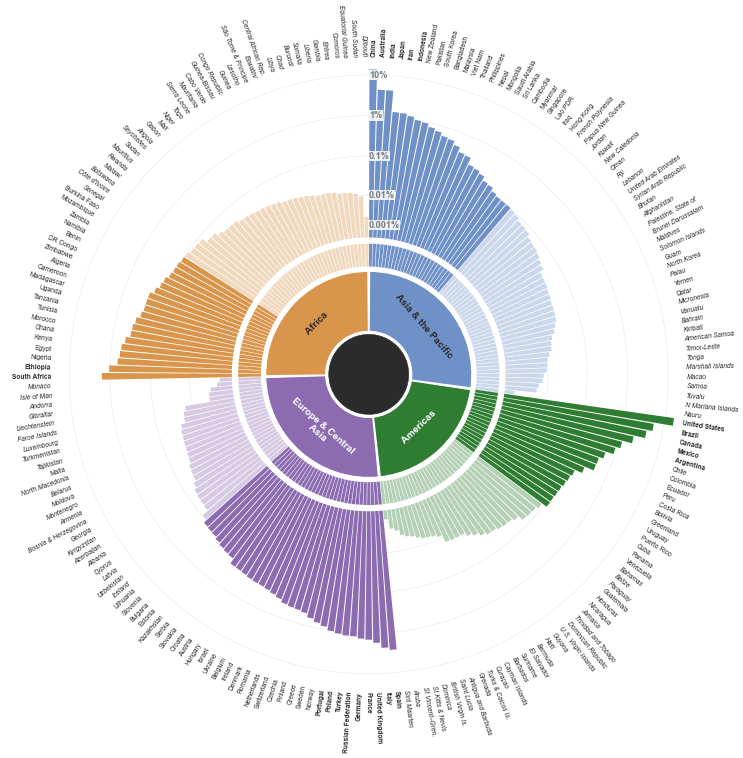

In [7]:
publication_figure = plot_geographic_attention_radial(
    geography.countries,
    count_col="whole_publications",
    region_order=ATTENTION_CONFIG["region_order"],
    start_angle=ATTENTION_CONFIG["clockwise_start_angle"],
    region_colors=ATTENTION_CONFIG["region_colors"],
    low_attention_threshold_pct=ATTENTION_CONFIG["low_attention_threshold_pct"],
    highlight_attention_threshold_pct=ATTENTION_CONFIG["highlight_attention_threshold_pct"],
    attention_ticks_pct=[0.001, 0.01, 0.1, 1, 10],
    figsize=(7.5, 7.5),
)
visualization.save_figure(
    publication_figure,
    FIGURE_DIR / ATTENTION_CONFIG["reference_figure_filename"],
    formats=["pdf"],
    dpi=300,
    pad_inches=0.08,
)
plt.show()

## 4. Export

In [8]:
assert geography.countries["iso3"].is_unique
assert geography.countries["whole_publications"].gt(0).all()
assert geography.countries["attention_share_pct"].gt(0).all()
assert np.isclose(geography.countries["attention_share_pct"].sum(), 100.0)
assert np.isclose(geography.regions["attention_share_pct"].sum(), 100.0)

In [9]:
figure_path = FIGURE_DIR / f"{ATTENTION_CONFIG['reference_figure_filename']}.pdf"
for path in (country_path, region_path, figure_path):
    print(path.relative_to(PROJECT_ROOT))

manifest = {
    "result": "05_geography_attention",
    "method_details": {
        "analysis_scope": {
            "n_publications": int(geography.publication_count),
            "n_assignments": int(geography.assignment_count),
            "n_countries": int(len(geography.countries)),
            "n_regions": int(len(geography.regions)),
        },
        "attention": {
            "grain": "UT x country, region resolved per-country via the IPBES crosswalk",
            "fractional_weight_formula": (
                "w_i,c = 1 / (number of countries named by publication i); "
                "weights sum to one per publication across its named countries"
            ),
            "measures": {
                "whole_publications": "distinct articles naming the place, unweighted",
                "fractional_publication_equivalent": (
                    "additive fractional measure behind attention_share_pct and the wheel figure"
                ),
            },
        },
        "wheel_figure": {
            "region_order": ATTENTION_CONFIG["region_order"],
            "start_angle_degrees": ATTENTION_CONFIG["clockwise_start_angle"],
            "low_attention_threshold_pct": ATTENTION_CONFIG["low_attention_threshold_pct"],
            "highlight_attention_threshold_pct": ATTENTION_CONFIG["highlight_attention_threshold_pct"],
        },
    },
    "artifacts": {
        "csv/country_attention.csv": "Per-country fractional research-attention share.",
        "csv/region_attention.csv": "Per-IPBES-region fractional research-attention share.",
        "figures/geography_attention_hierarchy_reference.pdf": (
            "Region -> country research-attention wheel."
        ),
    },
}
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
print(manifest_path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/05_geography_attention/csv/country_attention.csv
notebooks/results/outputs/05_geography_attention/csv/region_attention.csv
notebooks/results/outputs/05_geography_attention/figures/geography_attention_hierarchy_reference.pdf
notebooks/results/outputs/05_geography_attention/manifest.json
